# ASSIGNMENT 13: GENERATIVE AI ESSENTIALS

**Name:** OBAJE PAUL
**Course:** MACHINE LEARNING

## Introduction

Generative Artificial Intelligence (Generative AI) refers to artificial intelligence systems that can create new content such as text, images, audio, and code. Unlike traditional machine learning systems that are mainly designed to classify or predict existing data, generative models learn patterns from training data and use those patterns to produce new content.

This assignment explores the basic concepts behind Generative AI, with particular attention to Generative Pre-trained Transformers (GPTs), text generation, tokenization, attention mechanisms, and probability-based sequence generation.

For the practical implementation, a publicly available text dataset from Project Gutenberg is used to train a basic text generation model using Python and TensorFlow/Keras. The trained model is then used to generate text from a given seed input.

The assignment also discusses practical applications of Generative AI and important ethical issues such as bias, misinformation, copyright, and privacy.


## Dataset Selection

For this project, a text from **Project Gutenberg** was selected as the training dataset. Project Gutenberg provides a large collection of freely available eBooks, including many works that are in the public domain.

A single book is more suitable for this practical exercise than a very large dataset because the aim is to demonstrate the basic process of text generation in Google Colab rather than train a large language model.

The selected text will be downloaded directly in the notebook and used to train a small character-level text generation model.


In [1]:
# TODO: Import the required libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow version: 2.20.0
Libraries imported successfully.


## Dataset Preparation

The selected dataset is the full text of *Alice's Adventures in Wonderland* by Lewis Carroll. The text is suitable for this project because it provides enough sentences and characters for a simple text-generation model to learn common patterns in the writing.

The text is downloaded directly from Project Gutenberg so that the notebook can reproduce the dataset preparation process.


In [2]:
# TODO: Download the selected public text dataset

import requests

url = "https://www.gutenberg.org/files/11/11-0.txt"

response = requests.get(url)

text = response.text

print("Dataset downloaded successfully.")
print("Number of characters:", len(text))
print("\nFirst 500 characters:\n")
print(text[:500])

Dataset downloaded successfully.
Number of characters: 144696

First 500 characters:

*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The


## Text Cleaning

The downloaded text contains some introductory information from Project Gutenberg in addition to the actual book. The text will therefore be cleaned before training.

For this project, the text is converted to lowercase and unnecessary characters are removed. Limiting the dataset to a manageable number of characters also helps the model train efficiently in Google Colab.


In [3]:
# TODO: Clean and prepare the text

# Convert text to lowercase
text = text.lower()

# Keep only letters, numbers, spaces, and common punctuation
allowed_characters = "abcdefghijklmnopqrstuvwxyz0123456789 .,!?;:'\"-()\n"

text = ''.join(
    character for character in text
    if character in allowed_characters
)

# Use a manageable portion of the dataset for training
max_characters = 100000
text = text[:max_characters]

print("Text cleaned successfully.")
print("Characters used for training:", len(text))
print("\nSample of cleaned text:\n")
print(text[:500])

Text cleaned successfully.
Characters used for training: 100000

Sample of cleaned text:

 start of the project gutenberg ebook 11 

illustration




alices adventures in wonderland

by lewis carroll

the millennium fulcrum edition 3.0

contents

 chapter i.     down the rabbit-hole
 chapter ii.    the pool of tears
 chapter iii.   a caucus-race and a long tale
 chapter iv.    the rabbit sends in a little bill
 chapter v.     advice from a caterpillar
 chapter vi.    pig and pepper
 chapter vii.   a mad tea-party
 chapter viii.  the queens croquet-ground
 chapter ix.    the mock turt


## Exploring the Dataset

Before preparing the text for training, some basic characteristics of the dataset are examined. The number of characters and unique characters provide an indication of the size and vocabulary of the dataset.

A character-level model does not use words as its basic unit. Instead, it learns patterns from individual characters and their sequences.


In [4]:
# TODO: Examine basic dataset statistics

unique_characters = sorted(list(set(text)))

print("Total characters:", len(text))
print("Unique characters:", len(unique_characters))
print("\nUnique characters:")
print(''.join(unique_characters))

Total characters: 100000
Unique characters: 40

Unique characters:

 !(),-.013:;?abcdefghijklmnopqrstuvwxyz


## Character-Level Tokenization

Tokenization is the process of converting text into numerical representations that a machine learning model can process.

For this implementation, character-level tokenization is used. Each unique character is assigned an integer ID. The text can then be converted into a sequence of numbers and later converted back into characters when generated text is produced.


In [5]:
# TODO: Create character-to-index and index-to-character mappings

char_to_index = {character: index for index, character in enumerate(unique_characters)}
index_to_char = {index: character for index, character in enumerate(unique_characters)}

encoded_text = np.array([char_to_index[character] for character in text])

print("Character mappings created successfully.")
print("Vocabulary size:", len(unique_characters))
print("\nFirst 20 encoded characters:")
print(encoded_text[:20])

Character mappings created successfully.
Vocabulary size: 40

First 20 encoded characters:
[ 1 32 33 14 31 33  1 28 19  1 33 21 18  1 29 31 28 23 18 16]


## Creating Training Sequences

The model needs examples showing how one sequence of characters can be used to predict the next character.

A sequence length of 40 characters is used. For each training example, the model receives 40 characters as input and learns to predict the character that comes immediately after the sequence.

This creates many input-output examples from the original text.


In [6]:
# TODO: Create input sequences and target characters

sequence_length = 40

X = []
y = []

# Create sequences from the encoded text
for i in range(len(encoded_text) - sequence_length):
    X.append(encoded_text[i:i + sequence_length])
    y.append(encoded_text[i + sequence_length])

X = np.array(X)
y = np.array(y)

print("Training sequences created successfully.")
print("Input shape:", X.shape)
print("Target shape:", y.shape)

Training sequences created successfully.
Input shape: (99960, 40)
Target shape: (99960,)


## Preparing the Training Data

The complete text produces a large number of overlapping sequences. Since this is an educational implementation rather than a large-scale language model, a subset of the sequences is used to reduce training time.

The selected samples still contain enough text patterns to demonstrate the basic text-generation process.


In [7]:
# TODO: Limit the number of training sequences

max_sequences = 30000

X = X[:max_sequences]
y = y[:max_sequences]

print("Training data prepared.")
print("Number of sequences:", len(X))
print("Sequence length:", X.shape[1])

Training data prepared.
Number of sequences: 30000
Sequence length: 40


## Building the Text Generation Model

An LSTM (Long Short-Term Memory) neural network is used for the practical text-generation model.

LSTM networks are designed to learn patterns in sequential data. This makes them suitable for text because the order of characters is important when learning language patterns.

The model contains an embedding layer, an LSTM layer, and a dense output layer. The final layer produces a probability distribution across all possible characters.


In [8]:
# TODO: Build the LSTM text generation model

vocabulary_size = len(unique_characters)

model = Sequential([
    Embedding(
        input_dim=vocabulary_size,
        output_dim=64,
        input_length=sequence_length
    ),
    LSTM(128),
    Dense(vocabulary_size, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Training

The model is trained to predict the next character based on the previous 40 characters.

Sparse categorical cross-entropy is used as the loss function because the target is one character from the available vocabulary. During training, the model gradually adjusts its weights to improve its ability to predict the next character.

A small number of epochs is used because the purpose is to demonstrate the generative process rather than achieve production-level language modelling performance.


In [9]:
# TODO: Train the text generation model

epochs = 10

history = model.fit(
    X,
    y,
    epochs=epochs,
    batch_size=128,
    validation_split=0.1
)

print("Model training completed successfully.")

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 31s 137ms/step - accuracy: 0.2249 - loss: 2.8327 - val_accuracy: 0.3073 - val_loss: 2.5176
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 28s 133ms/step - accuracy: 0.3227 - loss: 2.3656 - val_accuracy: 0.3580 - val_loss: 2.2520
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 29s 136ms/step - accuracy: 0.3589 - loss: 2.2192 - val_accuracy: 0.3877 - val_loss: 2.1479
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 133ms/step - accuracy: 0.3805 - loss: 2.1325 - val_accuracy: 0.3930 - val_loss: 2.0827
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 28s 131ms/step - accuracy: 0.4005 - loss: 2.0645 - val_accuracy: 0.4163 - val_loss: 2.0287
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 27s 130ms/step - accuracy: 0.4194 - loss: 2.0052 - val_accuracy: 0.4397 - val_loss: 1.9758
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 28s 133ms/step - accuracy: 0.4326 - loss: 1.9490 - val_accuracy: 0.4543 - val_loss: 1.9295
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 131ms/step - accuracy: 0.4477 - loss: 1

## Training Results

The training loss is plotted to observe how the model learned during training. A decreasing loss generally indicates that the model is becoming better at predicting the next character in the training data.

The validation loss provides an additional indication of how the model performs on data that was not used directly for updating the model weights.


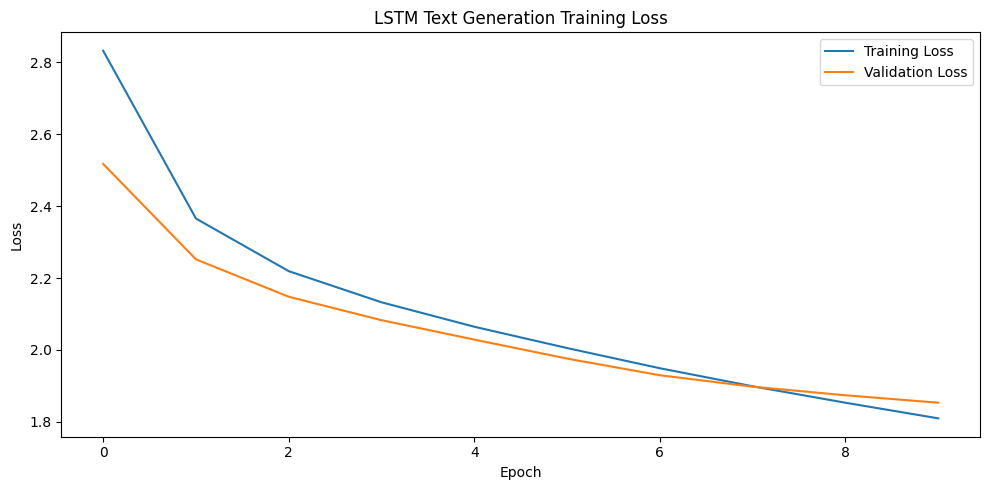

In [10]:
# TODO: Plot training and validation loss

plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Text Generation Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Text Generation

After training, the model can generate new text by starting with a seed sequence.

The model predicts a probability for every possible character. One character is selected and added to the sequence. The sequence is then updated and used to predict the next character.

This process is repeated until the requested amount of text has been generated.


In [11]:
# TODO: Create a function for generating new text

def generate_text(seed_text, generation_length=300):
    seed_text = seed_text.lower()

    # Make sure the seed contains only characters known by the model
    seed_text = ''.join(
        character for character in seed_text
        if character in char_to_index
    )

    if len(seed_text) == 0:
        seed_text = "alice"

    # Make the seed exactly sequence_length characters long
    if len(seed_text) < sequence_length:
        seed_text = seed_text.rjust(sequence_length)

    generated_text = seed_text

    for _ in range(generation_length):
        input_sequence = generated_text[-sequence_length:]

        encoded_sequence = np.array([
            char_to_index[character]
            for character in input_sequence
        ])

        encoded_sequence = encoded_sequence.reshape(1, sequence_length)

        predictions = model.predict(
            encoded_sequence,
            verbose=0
        )

        predicted_index = np.argmax(predictions[0])

        predicted_character = index_to_char[predicted_index]

        generated_text += predicted_character

    return generated_text

In [12]:
# TODO: Generate text using a seed input

seed_text = "alice"

generated_text = generate_text(
    seed_text,
    generation_length=500
)

print("Generated Text:")
print("----------------")
print(generated_text)

Generated Text:
----------------
                                   alice the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the 


## Testing Different Seed Inputs

The model can be tested with different seed inputs to observe how the starting text influences the generated sequence.

This demonstrates an important property of generative models: the output is influenced by both the patterns learned during training and the input provided by the user.


In [13]:
# TODO: Generate text from another seed

seed_text_2 = "the rabbit"

generated_text_2 = generate_text(
    seed_text_2,
    generation_length=400
)

print("Seed:", seed_text_2)
print("\nGenerated Text:")
print("----------------")
print(generated_text_2)

Seed: the rabbit

Generated Text:
----------------
                              the rabbit the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the


## Practical Application: Creative Story Generation

A simple content-creation application was implemented using the trained model. The application accepts a short seed phrase and uses the model to continue the text.

For example, a user can provide a starting phrase such as "once upon a time" and the model will generate a continuation based on patterns learned from the training text.

This demonstrates how a generative model can be used as a basic creative writing assistant. Although the generated text may not always be grammatically correct or logically consistent, the example shows the fundamental idea behind AI-assisted content generation.


In [14]:
# TODO: Demonstrate the content creation application

story_seed = "once upon a time"

story_output = generate_text(
    story_seed,
    generation_length=500
)

print("Creative Content Generator")
print("==========================")
print("Seed:", story_seed)
print("\nGenerated Content:")
print(story_output)

Creative Content Generator
Seed: once upon a time

Generated Content:
                        once upon a time the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the was it the 


## Generative Pre-trained Transformers (GPTs)

Generative Pre-trained Transformers, commonly called GPTs, are language models based on the Transformer architecture. They are designed to understand patterns in text and generate new sequences one token at a time.

Unlike the LSTM used in this practical implementation, GPT models use Transformer decoder architecture and self-attention mechanisms. GPT models can process relationships between tokens across a sequence and use the information to predict the next token.

A typical GPT workflow begins with tokenization, where text is divided into tokens. The tokens are converted into numerical representations called embeddings. These representations are processed by Transformer layers containing self-attention and feed-forward neural networks.

During training, GPT models learn by predicting the next token in a sequence. The model compares its prediction with the actual next token and adjusts its parameters to reduce the prediction error.

During generation, the model receives a sequence of tokens, calculates probabilities for possible next tokens, selects a token, adds it to the sequence, and repeats the process. This produces a generated sequence of text.


## How GPT Generates Text

The basic text-generation process of a GPT model can be summarized as:

**Text → Tokenization → Token Embeddings → Transformer Self-Attention → Probability Distribution → Next Token → Updated Sequence**

Tokenization converts the input into tokens that the model can process. The Transformer uses self-attention to determine which previous tokens are relevant when predicting the next token.

The output layer produces probabilities for possible next tokens. The model then selects a token according to the generation strategy being used. The selected token is added to the input sequence and the process continues.

This repeated next-token prediction is the fundamental mechanism behind autoregressive text generation.


## LSTM Model Compared with GPT

The practical model in this assignment uses an LSTM, while GPT uses a Transformer decoder architecture.

The LSTM processes sequences using recurrent connections and maintains information through its hidden and cell states. GPT instead uses self-attention, allowing it to model relationships between tokens within the context.

The LSTM implementation is much smaller and easier to train in Google Colab. It is therefore suitable for demonstrating the basic concept of generative text modelling, while modern GPT models are much larger and require substantially more training data and computational resources.


## Applications of Generative AI

Generative AI can be applied in many areas because it can produce new content based on learned patterns. Common applications include:

* **Content creation:** generating stories, articles, descriptions, and other written content.
* **Education:** creating explanations, practice questions, summaries, and learning materials.
* **Programming:** assisting with code generation, debugging, and documentation.
* **Customer service:** generating responses to common customer questions.
* **Marketing:** creating advertising ideas, product descriptions, and social media content.
* **Creative work:** assisting with stories, scripts, ideas, and other creative material.

These applications can improve productivity, but their outputs should still be reviewed by humans because generative models can produce incorrect or misleading information.


## Ethical Considerations

Generative AI provides useful capabilities, but it also creates several ethical challenges.

**Bias:** Models can learn biases present in their training data and reproduce them in generated content. Using diverse and carefully reviewed training data can help reduce this problem.

**Misinformation:** Generative models can produce text that sounds convincing even when it is incorrect. Human review, fact checking, and clear disclosure of AI-generated content can reduce this risk.

**Copyright:** Training data and generated content can raise questions about ownership and the use of copyrighted material. Using appropriately licensed or public-domain datasets and respecting copyright restrictions are important.

**Privacy:** Training data may contain personal or sensitive information. Data should therefore be collected and processed responsibly, with unnecessary personal information removed.

**Lack of accountability:** AI-generated content can make it difficult to determine who is responsible for harmful output. Human oversight should remain part of important AI-assisted decisions.

Responsible use of Generative AI requires a combination of technical safeguards, appropriate data practices, transparency, and human supervision.


## Findings

The practical implementation demonstrated that a relatively small LSTM model can learn character patterns from a text dataset and generate new sequences based on a seed input.

The generated text showed that the model learned some of the spelling, punctuation, and character-level patterns present in the training material. However, the output may contain grammatical errors, repeated patterns, or sentences that do not have a clear meaning.

This limitation is expected because the model is small and was trained on a limited amount of text. It also operates at the character level rather than using a more advanced token-based Transformer architecture.

The experiment therefore demonstrates the basic principles of generative text modelling while showing why larger datasets and more advanced architectures are needed for high-quality language generation.


## Conclusion

This assignment provided an introduction to Generative AI and demonstrated how machine learning models can be used to generate new text.

A publicly available Project Gutenberg text was prepared and converted into character-level training sequences. An LSTM model was then trained using TensorFlow/Keras and used to generate text from different seed inputs. A simple creative content-generation application was also demonstrated.

The assignment also examined GPT architecture and explained the roles of tokenization, embeddings, self-attention, probabilities, and autoregressive sequence generation. While the practical model used an LSTM rather than a Transformer, it demonstrated the fundamental concept of predicting and generating sequential text.

Generative AI has significant potential in areas such as content creation, education, programming, marketing, and customer service. However, issues including bias, misinformation, copyright, privacy, and accountability need to be addressed through responsible data practices and human oversight.

Future developments in Generative AI are likely to focus on more capable models, better reliability, improved reasoning, stronger safety mechanisms, and more responsible applications.


In [15]:
# TODO: Display a final project summary

print("Assignment 13: Generative AI Essentials")
print("---------------------------------------")
print("Dataset: Project Gutenberg - Alice's Adventures in Wonderland")
print("Model: LSTM text generation model")
print("Framework: TensorFlow/Keras")
print("Task: Character-level text generation")
print("Application: Creative content generation")
print("\nAssignment implementation completed successfully.")

Assignment 13: Generative AI Essentials
---------------------------------------
Dataset: Project Gutenberg - Alice's Adventures in Wonderland
Model: LSTM text generation model
Framework: TensorFlow/Keras
Task: Character-level text generation
Application: Creative content generation

Assignment implementation completed successfully.
